# 🍷 Wine Quality Prediction
## Cases C Machine Learning Project

This notebook compares six feature-engineering cases for regression and classification.

## 1. Introduction
The objective is to predict wine quality from physicochemical measurements. We compare regression and classification approaches and investigate the effect of converting selected continuous variables into categories.

In [260]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import classification_report

## 2. Load Dataset

In [261]:
wine_df = pd.read_csv("WineQT.csv")
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 3. Initial Exploration

In [262]:
wine_df.info()
wine_df.describe()
wine_df.isnull().sum()
wine_df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


np.int64(0)

## 4. Exploratory Data Analysis

In [263]:
wine_df = wine_df.drop(columns='Id')

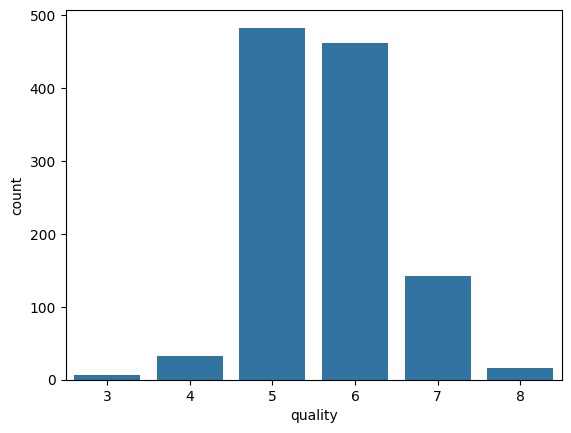

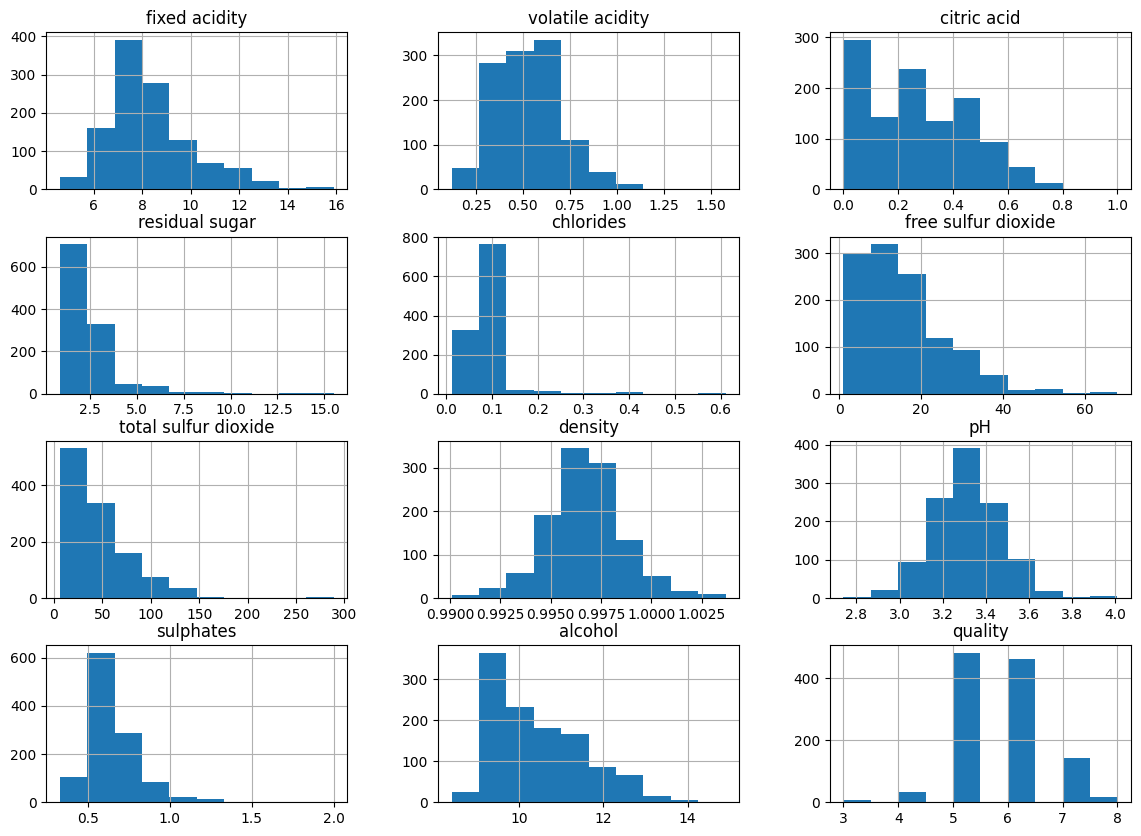

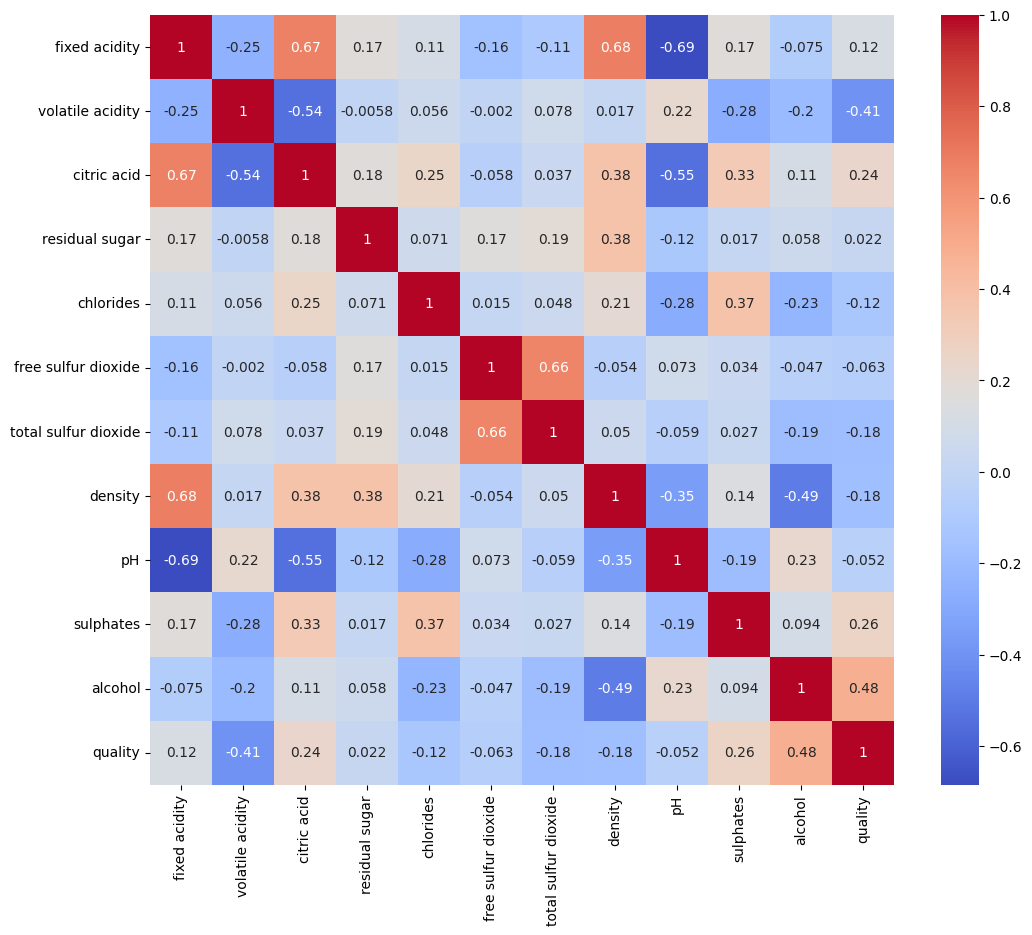

In [264]:
sns.countplot(data=wine_df,x='quality')
plt.show()

wine_df.hist(figsize=(14,10))
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(wine_df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

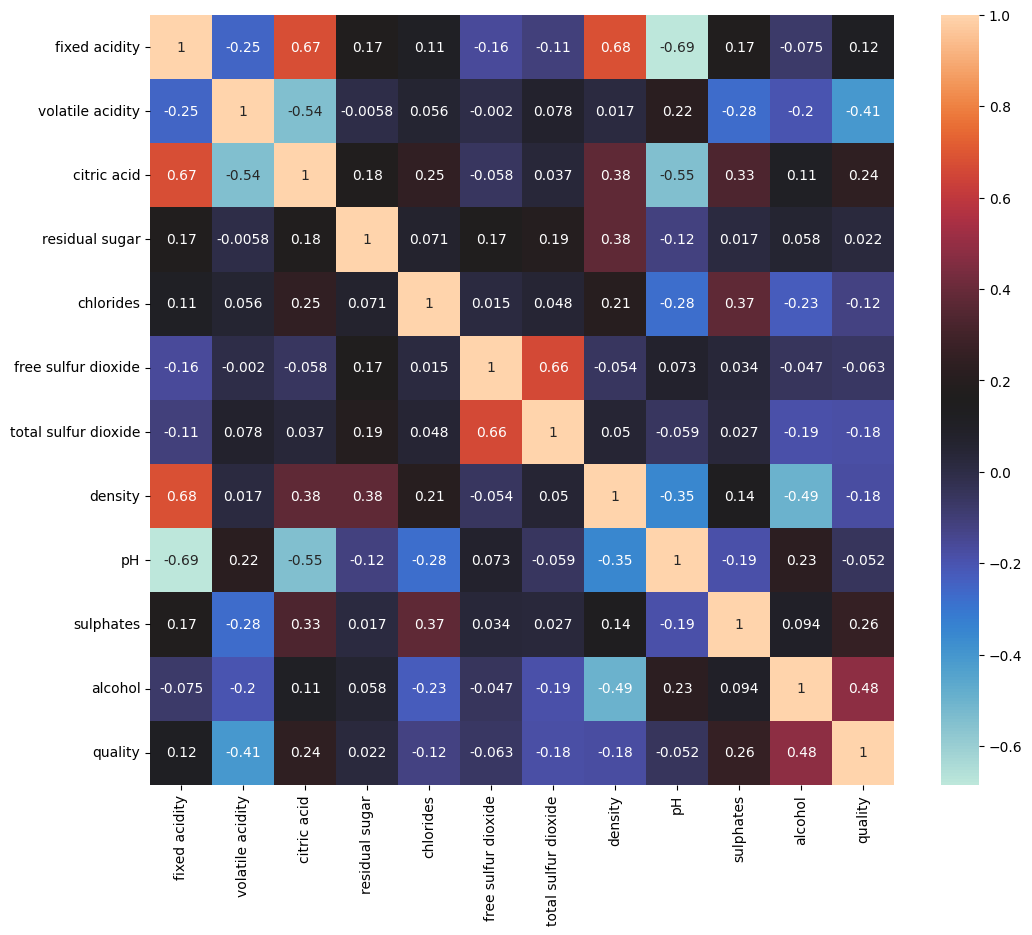

In [265]:
plt.figure(figsize=(12,10))
sns.heatmap(wine_df.corr(numeric_only=True),annot=True,cmap='icefire')
plt.show()

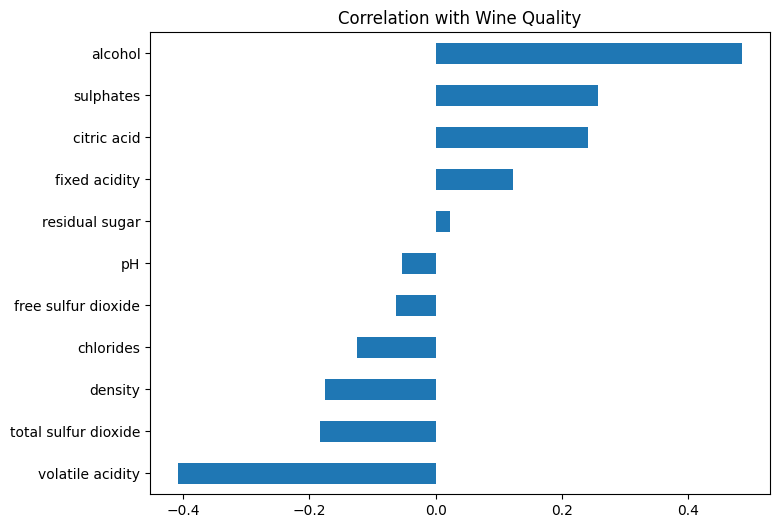

In [266]:
quality_corr = (
    wine_df
    .corr(numeric_only=True)["quality"]
    .drop("quality")
    .sort_values()
)

plt.figure(figsize=(8,6))

quality_corr.plot(kind="barh")

plt.title("Correlation with Wine Quality")

plt.show()

## 5. Data Cleaning

In [267]:
#Id was dropped in before EDA
selected_features_df = wine_df.drop(columns=['volatile acidity'])
selected_features_df.head(5)

,fixed acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 6. Feature Engineering
Create Cases 1–6 (baseline, pH categorical, pH+Residual Sugar categorical for both regression and classification).

In [268]:
case_11num = selected_features_df.copy()

### Categorize pH

In [269]:
case_10num = selected_features_df.copy()

# Create the categorical variable
case_10num['pH_cat'] = pd.cut(
    case_10num['pH'],
    bins=[0, 3.2, 3.5, 10],
    labels=['HighAcidity', 'Medium', 'LowAcidity']
)

# Initialize the encoder (keep all categories)
encoder_pH = OneHotEncoder(sparse_output=False)

# Encode the categorical feature
encoded_pH = encoder_pH.fit_transform(case_10num[['pH_cat']])

# Create a DataFrame with the encoded columns
encoded_pH_df = pd.DataFrame(
    encoded_pH,
    columns=encoder_pH.get_feature_names_out(['pH_cat']),
    index=case_10num.index
)

# Drop the original columns and concatenate the encoded ones
case_10num  = pd.concat(
    [case_10num .drop(columns=['pH', 'pH_cat']), encoded_pH_df],
    axis=1
)
case_10num.head(5)

,fixed acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,sulphates,alcohol,quality,pH_cat_HighAcidity,pH_cat_LowAcidity,pH_cat_Medium
0,7.4,0.00,1.9,0.076,11.0,34.0,0.9978,0.56,9.4,5,0.0,1.0,0.0
1,7.8,0.00,2.6,0.098,25.0,67.0,0.9968,0.68,9.8,5,1.0,0.0,0.0
2,7.8,0.04,2.3,0.092,15.0,54.0,0.9970,0.65,9.8,5,0.0,0.0,1.0
3,11.2,0.56,1.9,0.075,17.0,60.0,0.9980,0.58,9.8,6,1.0,0.0,0.0
4,7.4,0.00,1.9,0.076,11.0,34.0,0.9978,0.56,9.4,5,0.0,1.0,0.0


### Categorize ResidualSugar

In [270]:
case_9num = case_10num.copy()

# Create the categorical variable
case_9num['ResidualSugar_cat'] = pd.cut(
    case_9num['residual sugar'],
    bins=[0, 4, 12, 100],
    labels=['Dry', 'OffDry', 'Sweet']
)

# Initialize the encoder (keep all categories)
encoder_sugar = OneHotEncoder(sparse_output=False)

# Encode the categorical feature
encoded_sugar = encoder_sugar.fit_transform(case_9num[['ResidualSugar_cat']])

# Create a DataFrame with the encoded columns
encoded_sugar_df = pd.DataFrame(
    encoded_sugar,
    columns=encoder_sugar.get_feature_names_out(['ResidualSugar_cat']),
    index=case_9num.index
)

# Drop the original columns and concatenate the encoded ones
case_9num = pd.concat(
    [case_9num.drop(columns=['residual sugar', 'ResidualSugar_cat']), encoded_sugar_df],
    axis=1
)
case_9num.head(5)

,fixed acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,density,sulphates,alcohol,quality,pH_cat_HighAcidity,pH_cat_LowAcidity,pH_cat_Medium,ResidualSugar_cat_Dry,ResidualSugar_cat_OffDry,ResidualSugar_cat_Sweet
0,7.4,0.00,0.076,11.0,34.0,0.9978,0.56,9.4,5,0.0,1.0,0.0,1.0,0.0,0.0
1,7.8,0.00,0.098,25.0,67.0,0.9968,0.68,9.8,5,1.0,0.0,0.0,1.0,0.0,0.0
2,7.8,0.04,0.092,15.0,54.0,0.9970,0.65,9.8,5,0.0,0.0,1.0,1.0,0.0,0.0
3,11.2,0.56,0.075,17.0,60.0,0.9980,0.58,9.8,6,1.0,0.0,0.0,1.0,0.0,0.0
4,7.4,0.00,0.076,11.0,34.0,0.9978,0.56,9.4,5,0.0,1.0,0.0,1.0,0.0,0.0


## 8. Modeling

**_Preparation:_** <br>
Implement reusable functions to evaluate regression and classification models across all cases.

**_Modeling_**<br>
All cases (regression and classification will follow the steps:
1. Split each case into features and target (x-y)
2. Split into train and test
3. Scale (where appropriate - with algorithms that are sensitive to feature scale (e.g., KNN, Logistic Regression.)
4. Evaluate Model
   - Regression
   -Classification
6. Store results in comparison tables 



### **_Preparation_**

In [271]:
def regression_metrics(model,X_train,X_test,y_train,y_test):
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    return {
        'MAE':mean_absolute_error(y_test,pred),
        'RMSE':mean_squared_error(y_test,pred),
        'R2':r2_score(y_test,pred)
    }

def classification_metrics(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    print("Predicted classes:", np.unique(pred))


    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test,
            pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred,
            average="weighted",
            zero_division=0
        )
    }

### **_Modeling_**

#### Case 1

**Regression** <br>
**Numerical Features**


In [272]:
# 1. Split each case into X and y.
features_case_1 = case_11num.drop(columns='quality')
target_case_1 = case_11num['quality']


In [273]:
# 2. Train/test split.
X_train, X_test, y_train, y_test = train_test_split(
    features_case_1,
    target_case_1,
    test_size=0.20,
    random_state=17
)


In [274]:
# 3. Scale where appropriate.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [275]:
# 4. Evaluate Linear/Logistic, KNN, Decision Tree, Random Forest.

results_regression_case_1 = []

# Linear Regression - instanciate it and then pass it to the reusable function
lr = LinearRegression()

metrics = regression_metrics(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

metrics["Case"] = "Case 1"
metrics["Model"] = "Linear Regression"

results_regression_case_1.append(metrics)

# -----------------------------
# KNN Regressor
# -----------------------------

for k in [1, 3, 5, 10, 20, 50]:

    knn = KNeighborsRegressor(n_neighbors=k)

    metrics = regression_metrics(
        knn,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    metrics["Case"] = "Case 1"
    metrics["Model"] = f"KNN (k={k})"

    results_regression_case_1.append(metrics)

# -----------------------------
# Decision Tree
# -----------------------------

dt = DecisionTreeRegressor(random_state=17)

metrics = regression_metrics(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 1"
metrics["Model"] = "Decision Tree"

results_regression_case_1.append(metrics)

# -----------------------------
# Random Forest
# -----------------------------

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=17
)

metrics = regression_metrics(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 1"
metrics["Model"] = "Random Forest"

results_regression_case_1.append(metrics)


In [276]:
# 5. Store results in comparison tables.
results_case1 = pd.DataFrame(results_regression_case_1)

results_case1 = results_case1[
    ["Case", "Model", "MAE", "RMSE", "R2"]
]

results_case1.sort_values(
    by="R2",
    ascending=False,
    inplace=True
)

results_case1.reset_index(drop=True, inplace=True)

results_case1

,Case,Model,MAE,RMSE,R2
0,Case 1,Random Forest,0.446550,0.363626,0.408496
1,Case 1,Linear Regression,0.482664,0.386578,0.371159
2,Case 1,KNN (k=50),0.527336,0.427270,0.304967
3,Case 1,KNN (k=20),0.513319,0.428286,0.303314
4,Case 1,KNN (k=10),0.520961,0.463974,0.245262
5,Case 1,KNN (k=5),0.540611,0.508472,0.172878
6,Case 1,KNN (k=3),0.537118,0.541000,0.119965
7,Case 1,KNN (k=1),0.502183,0.676856,-0.101030
8,Case 1,Decision Tree,0.489083,0.681223,-0.108133


#### Case 2

In [277]:
# 1. Split each case into X and y.
features_case_2 = case_10num.drop(columns='quality')
target_case_2 = case_10num['quality']

# 2. Train/test split.
X_train, X_test, y_train, y_test = train_test_split(
    features_case_2,
    target_case_2,
    test_size=0.20,
    random_state=17
)

In [278]:
# 3. Scale where appropriate.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [279]:
# 4. Evaluate Linear/Logistic, KNN, Decision Tree, Random Forest.

results_regression_case_2 = []

# Linear Regression - instanciate it and then pass it to the reusable function
lr = LinearRegression()

metrics = regression_metrics(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

metrics["Case"] = "Case 2"
metrics["Model"] = "Linear Regression"

results_regression_case_2.append(metrics)

# -----------------------------
# KNN Regressor
# -----------------------------

for k in [1, 3, 5, 10, 20, 50]:

    knn = KNeighborsRegressor(n_neighbors=k)

    metrics = regression_metrics(
        knn,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    metrics["Case"] = "Case 2"
    metrics["Model"] = f"KNN (k={k})"

    results_regression_case_2.append(metrics)

# -----------------------------
# Decision Tree
# -----------------------------

dt = DecisionTreeRegressor(random_state=17)

metrics = regression_metrics(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 2"
metrics["Model"] = "Decision Tree"

results_regression_case_2.append(metrics)

# -----------------------------
# Random Forest
# -----------------------------

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=17
)

metrics = regression_metrics(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 2"
metrics["Model"] = "Random Forest"

results_regression_case_2.append(metrics)

In [280]:
# -----------------------------
# 5. Create Comparison Table
# -----------------------------

results_case2 = pd.DataFrame(results_regression_case_2)

results_case2 = results_case2[
    ["Case", "Model", "MAE", "RMSE", "R2"]
]

results_case2.sort_values(
    by="R2",
    ascending=False,
    inplace=True
)

results_case2.reset_index(drop=True, inplace=True)

results_case2

,Case,Model,MAE,RMSE,R2
0,Case 2,Random Forest,0.451965,0.377063,0.386638
1,Case 2,Linear Regression,0.485635,0.387123,0.370273
2,Case 2,KNN (k=50),0.524541,0.419741,0.317214
3,Case 2,KNN (k=20),0.523362,0.437063,0.289037
4,Case 2,KNN (k=10),0.507860,0.441179,0.282342
5,Case 2,KNN (k=5),0.519651,0.486114,0.209247
6,Case 2,KNN (k=3),0.510917,0.510917,0.168900
7,Case 2,KNN (k=1),0.484716,0.650655,-0.058409
8,Case 2,Decision Tree,0.506550,0.733624,-0.193374


#### Case 3

In [281]:
# 1. Split each case into X and y.
features_case_3 = case_9num.drop(columns='quality')
target_case_3 = case_9num['quality']

# 2. Train/test split.
X_train, X_test, y_train, y_test = train_test_split(
    features_case_3,
    target_case_3,
    test_size=0.20,
    random_state=17
)

In [282]:
# 3. Scale where appropriate.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [283]:
# 4. Evaluate Linear/Logistic, KNN, Decision Tree, Random Forest.

results_regression_case_3 = []

# Linear Regression - instanciate it and then pass it to the reusable function
lr = LinearRegression()

metrics = regression_metrics(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

metrics["Case"] = "Case 3"
metrics["Model"] = "Linear Regression"

results_regression_case_3.append(metrics)

# -----------------------------
# KNN Regressor
# -----------------------------

for k in [1, 3, 5, 10, 20, 50]:

    knn = KNeighborsRegressor(n_neighbors=k)

    metrics = regression_metrics(
        knn,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    metrics["Case"] = "Case 3"
    metrics["Model"] = f"KNN (k={k})"

    results_regression_case_3.append(metrics)

# -----------------------------
# Decision Tree
# -----------------------------

dt = DecisionTreeRegressor(random_state=17)

metrics = regression_metrics(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 3"
metrics["Model"] = "Decision Tree"

results_regression_case_3.append(metrics)

# -----------------------------
# Random Forest
# -----------------------------

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=17
)

metrics = regression_metrics(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 3"
metrics["Model"] = "Random Forest"

results_regression_case_3.append(metrics)


In [284]:
# -----------------------------
# 5. Create Comparison Table
# -----------------------------

results_case3 = pd.DataFrame(results_regression_case_3)

results_case3 = results_case3[
    ["Case", "Model", "MAE", "RMSE", "R2"]
]

results_case3.sort_values(
    by="R2",
    ascending=False,
    inplace=True
)

results_case3.reset_index(drop=True, inplace=True)

results_case3

,Case,Model,MAE,RMSE,R2
0,Case 3,Random Forest,0.454323,0.378979,0.383521
1,Case 3,Linear Regression,0.492473,0.397710,0.353053
2,Case 3,KNN (k=20),0.524017,0.425830,0.307310
3,Case 3,KNN (k=50),0.531703,0.425890,0.307212
4,Case 3,KNN (k=10),0.506550,0.429520,0.301308
5,Case 3,KNN (k=5),0.517031,0.465328,0.243060
6,Case 3,KNN (k=3),0.524017,0.512373,0.166532
7,Case 3,KNN (k=1),0.445415,0.593886,0.033935
8,Case 3,Decision Tree,0.462882,0.593886,0.033935


All regression cases:

In [285]:
all_regression_results = pd.concat(
    [results_case1, results_case2, results_case3],
    ignore_index=True
)

all_regression_results.sort_values(
    by="R2",
    ascending=False
)

all_regression_results

,Case,Model,MAE,RMSE,R2
0,Case 1,Random Forest,0.446550,0.363626,0.408496
1,Case 1,Linear Regression,0.482664,0.386578,0.371159
2,Case 1,KNN (k=50),0.527336,0.427270,0.304967
3,Case 1,KNN (k=20),0.513319,0.428286,0.303314
4,Case 1,KNN (k=10),0.520961,0.463974,0.245262
5,Case 1,KNN (k=5),0.540611,0.508472,0.172878
6,Case 1,KNN (k=3),0.537118,0.541000,0.119965
7,Case 1,KNN (k=1),0.502183,0.676856,-0.101030
8,Case 1,Decision Tree,0.489083,0.681223,-0.108133
9,Case 2,Random Forest,0.451965,0.377063,0.386638


#### Case 4

In [286]:
#1. Split each case into features and target (x-y)
features_case_4 = case_11num.drop(columns='quality')
target_case_4 = case_11num['quality'].astype(int)
# Adding .astype(int) makes it explicit that quality is being treated as class label,
# and helps avoid issues if the column were accidentally loaded as floats.

#2. Split into train and test
# Stratify is added becausequalities 3,4, and 8 are relatively rare.
# Stratification ensures that both the training and testing datasets contain
#  approximately the same proportion of each quality level.

X_train, X_test, y_train, y_test = train_test_split(
    features_case_4,
    target_case_4,
    test_size=0.20,
    random_state=17,
    stratify=target_case_4 
)

In [287]:
#3. Scale (where appropriate)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [288]:
#4. Evaluate Model
results_classification_case4 = []

# -----------------------------
# Logistic Regression
# -----------------------------
#Although the target is multiclass, Scikit-learn automatically performs multinomial logistic regression.
log_model = LogisticRegression(
    max_iter=1000,
    random_state=17
)

metrics = classification_metrics(
    log_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

metrics["Case"] = "Case 4"
metrics["Model"] = "Logistic Regression"

results_classification_case4.append(metrics)

# -----------------------------
# K-Nearest Neighbours
# -----------------------------
for k in [1,3,5,10,20,50]:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    metrics = classification_metrics(
        knn,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    metrics["Case"] = "Case 4"
    metrics["Model"] = f"KNN (k={k})"

    results_classification_case4.append(metrics)

# -----------------------------
# Decision Tree
# -----------------------------
tree = DecisionTreeClassifier(
    random_state=17
)

metrics = classification_metrics(
    tree,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 4"
metrics["Model"] = "Decision Tree"

results_classification_case4.append(metrics)

# -----------------------------
# Random Forest
# -----------------------------
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=17
)

metrics = classification_metrics(
    forest,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 4"
metrics["Model"] = "Random Forest"

results_classification_case4.append(metrics)


Predicted classes: [5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7]
Predicted classes: [4 5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [5 6 7]


In [289]:
print(sorted(y_train.unique()))
print(sorted(y_test.unique()))

[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [290]:
log_model.fit(X_train_scaled, y_train)

pred = log_model.predict(X_test_scaled)

print("Predicted classes:", np.unique(pred))

Predicted classes: [5 6 7 8]


In [291]:
#5. Store results in comparison tables
results_case4 = pd.DataFrame(results_classification_case4)

results_case4 = results_case4[
    [
        "Case",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

results_case4 = results_case4.sort_values(
    by="Accuracy",
    ascending=False
)

results_case4.reset_index(drop=True, inplace=True)

results_case4

,Case,Model,Accuracy,Precision,Recall,F1
0,Case 4,Random Forest,0.615721,0.587216,0.615721,0.601088
1,Case 4,Logistic Regression,0.576419,0.546130,0.576419,0.548796
2,Case 4,KNN (k=20),0.558952,0.522464,0.558952,0.533106
3,Case 4,KNN (k=1),0.554585,0.547673,0.554585,0.549877
4,Case 4,KNN (k=5),0.545852,0.520945,0.545852,0.530818
5,Case 4,Decision Tree,0.541485,0.533759,0.541485,0.536833
6,Case 4,KNN (k=10),0.524017,0.492610,0.524017,0.504086
7,Case 4,KNN (k=3),0.515284,0.507790,0.515284,0.509489
8,Case 4,KNN (k=50),0.506550,0.481886,0.506550,0.483734


#### Case 5

In [292]:
#1. Split each case into features and target (x-y)
features_case_5 = case_10num.drop(columns='quality')
target_case_5 = case_10num['quality'].astype(int)

#2. Split into train and test

X_train, X_test, y_train, y_test = train_test_split(
    features_case_5,
    target_case_5,
    test_size=0.20,
    random_state=17,
    stratify=target_case_5
)

In [293]:
#3. Scale (where appropriate)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [294]:
#4. Evaluate Model
results_classification_case5 = []

# -----------------------------
# Logistic Regression
# -----------------------------
#Although the target is multiclass, Scikit-learn automatically performs multinomial logistic regression.
log_model = LogisticRegression(
    max_iter=1000,
    random_state=17
)

metrics = classification_metrics(
    log_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

metrics["Case"] = "Case 5"
metrics["Model"] = "Logistic Regression"

results_classification_case5.append(metrics)

# -----------------------------
# K-Nearest Neighbours
# -----------------------------
for k in [1,3,5,10,20,50]:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    metrics = classification_metrics(
        knn,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    metrics["Case"] = "Case 5"
    metrics["Model"] = f"KNN (k={k})"

    results_classification_case5.append(metrics)

# -----------------------------
# Decision Tree
# -----------------------------
tree = DecisionTreeClassifier(
    random_state=17
)

metrics = classification_metrics(
    tree,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 5"
metrics["Model"] = "Decision Tree"

results_classification_case5.append(metrics)

# -----------------------------
# Random Forest
# -----------------------------
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=17
)

metrics = classification_metrics(
    forest,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 5"
metrics["Model"] = "Random Forest"

results_classification_case5.append(metrics)


Predicted classes: [5 6 7]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7]
Predicted classes: [4 5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [5 6 7]


In [295]:
#5. Store results in comparison tables
results_case5 = pd.DataFrame(results_classification_case5)

results_case5 = results_case5[
    [
        "Case",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

results_case5 = results_case5.sort_values(
    by="Accuracy",
    ascending=False
)

results_case5.reset_index(drop=True, inplace=True)

results_case5

,Case,Model,Accuracy,Precision,Recall,F1
0,Case 5,Random Forest,0.620087,0.589079,0.620087,0.604069
1,Case 5,Logistic Regression,0.611354,0.579871,0.611354,0.587502
2,Case 5,KNN (k=1),0.580786,0.571661,0.580786,0.575255
3,Case 5,Decision Tree,0.550218,0.539786,0.550218,0.544553
4,Case 5,KNN (k=20),0.541485,0.512719,0.541485,0.513379
5,Case 5,KNN (k=3),0.537118,0.523407,0.537118,0.529722
6,Case 5,KNN (k=50),0.537118,0.489426,0.537118,0.502215
7,Case 5,KNN (k=10),0.524017,0.487601,0.524017,0.498550
8,Case 5,KNN (k=5),0.524017,0.495869,0.524017,0.507661


#### Case 6

In [296]:
#1. Split each case into features and target (x-y)
features_case_6 = case_9num.drop(columns='quality')
target_case_6 = case_9num['quality'].astype(int)

#2. Split into train and test

X_train, X_test, y_train, y_test = train_test_split(
    features_case_6,
    target_case_6,
    test_size=0.20,
    random_state=17,
    stratify=target_case_6
)

In [297]:
#3. Scale (where appropriate)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [298]:
#4. Evaluate Model
results_classification_case6 = []

# -----------------------------
# Logistic Regression
# -----------------------------
#Although the target is multiclass, Scikit-learn automatically performs multinomial logistic regression.
log_model = LogisticRegression(
    max_iter=1000,
    random_state=17
)

metrics = classification_metrics(
    log_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

metrics["Case"] = "Case 6"
metrics["Model"] = "Logistic Regression"

results_classification_case6.append(metrics)

# -----------------------------
# K-Nearest Neighbours
# -----------------------------
for k in [1,3,5,10,20,50]:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    metrics = classification_metrics(
        knn,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    metrics["Case"] = "Case 6"
    metrics["Model"] = f"KNN (k={k})"

    results_classification_case6.append(metrics)

# -----------------------------
# Decision Tree
# -----------------------------
tree = DecisionTreeClassifier(
    random_state=17
)

metrics = classification_metrics(
    tree,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 6"
metrics["Model"] = "Decision Tree"

results_classification_case6.append(metrics)

# -----------------------------
# Random Forest
# -----------------------------
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=17
)

metrics = classification_metrics(
    forest,
    X_train,
    X_test,
    y_train,
    y_test
)

metrics["Case"] = "Case 6"
metrics["Model"] = "Random Forest"

results_classification_case6.append(metrics)


Predicted classes: [5 6 7]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [5 6 7]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [5 6 7]


In [299]:
#5. Store results in comparison tables
results_case6 = pd.DataFrame(results_classification_case6)

results_case6 = results_case6[
    [
        "Case",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

results_case6 = results_case6.sort_values(
    by="Accuracy",
    ascending=False
)

results_case6.reset_index(drop=True, inplace=True)

results_case6

,Case,Model,Accuracy,Precision,Recall,F1
0,Case 6,Random Forest,0.620087,0.588112,0.620087,0.603351
1,Case 6,Logistic Regression,0.598253,0.561400,0.598253,0.573567
2,Case 6,KNN (k=1),0.576419,0.560527,0.576419,0.567591
3,Case 6,Decision Tree,0.572052,0.567510,0.572052,0.568797
4,Case 6,KNN (k=10),0.545852,0.505485,0.545852,0.520550
5,Case 6,KNN (k=20),0.545852,0.509981,0.545852,0.522160
6,Case 6,KNN (k=3),0.532751,0.524324,0.532751,0.528321
7,Case 6,KNN (k=50),0.532751,0.487374,0.532751,0.495927
8,Case 6,KNN (k=5),0.528384,0.496392,0.528384,0.509009


## 9. Results
Create comparison tables for regression (R², RMSE) and classification (Accuracy, Precision, Recall).

### A - Regression

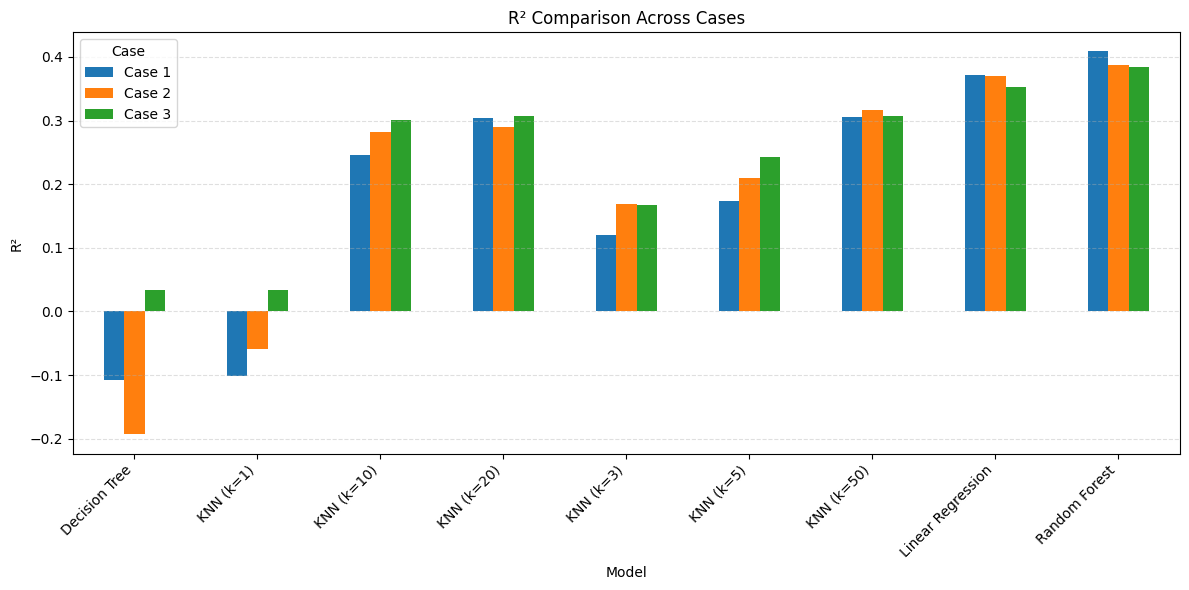

In [300]:

# Combine all regression results
results_all_regression = pd.concat(
    [results_case1, results_case2, results_case3],
    ignore_index=True
)

# Create a pivot table
r2_table = results_all_regression.pivot(
    index="Model",
    columns="Case",
    values="R2"
)

# Plot
ax = r2_table.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("R² Comparison Across Cases")
plt.ylabel("R²")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Case")
plt.tight_layout()

plt.show()

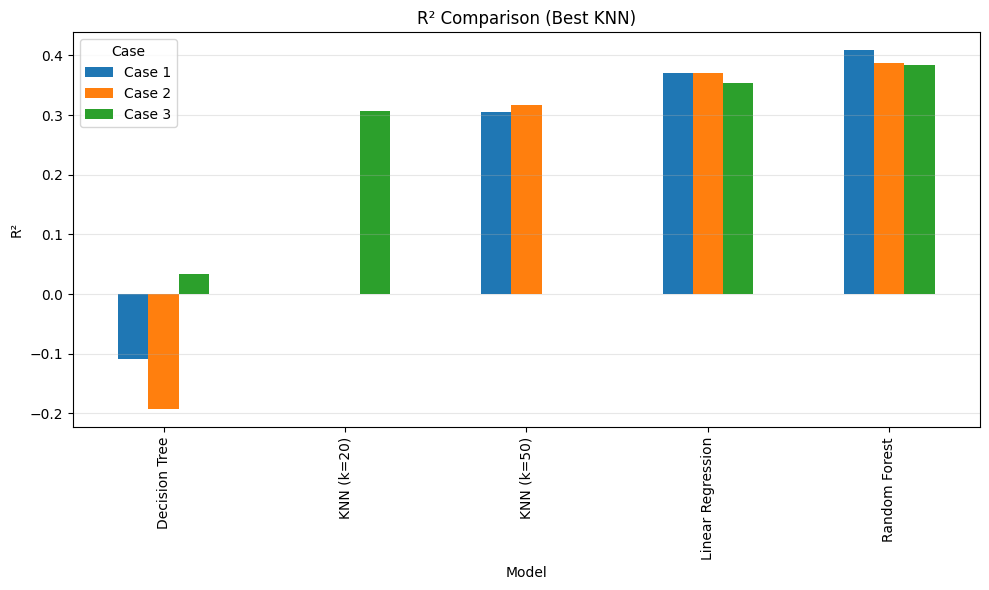

In [301]:
# Separate KNN models
knn = results_all_regression[results_all_regression["Model"].str.contains("KNN")]

# Keep the best KNN per case
best_knn = knn.loc[knn.groupby("Case")["R2"].idxmax()]

# Keep non-KNN models
others = results_all_regression[~results_all_regression["Model"].str.contains("KNN")]

# Combine
plot_df = pd.concat([others, best_knn], ignore_index=True)

# Pivot
r2_table = plot_df.pivot(
    index="Model",
    columns="Case",
    values="R2"
)

r2_table.plot(kind="bar", figsize=(10,6))

plt.title("R² Comparison (Best KNN)")
plt.ylabel("R²")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### B - Classification

In [302]:
results_all_classification = pd.concat(
    [
        results_case4,
        results_case5,
        results_case6
    ],
    ignore_index=True
)

In [303]:
accuracy_table = results_all_classification.pivot(
    index="Model",
    columns="Case",
    values="Accuracy"
)

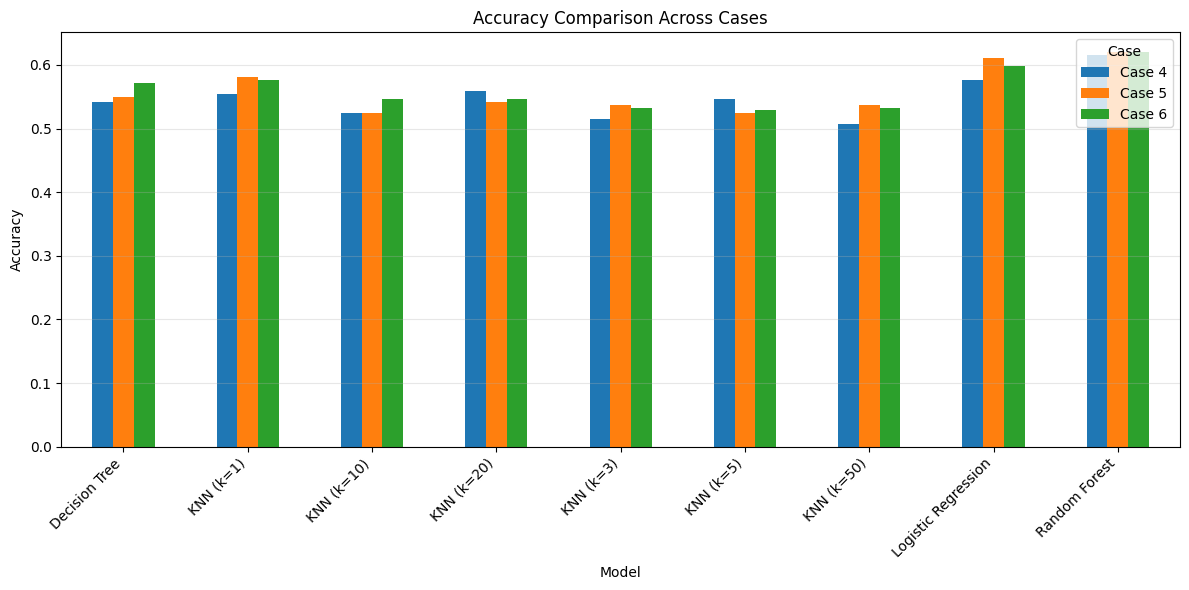

In [304]:
# Plot
accuracy_table.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Accuracy Comparison Across Cases")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

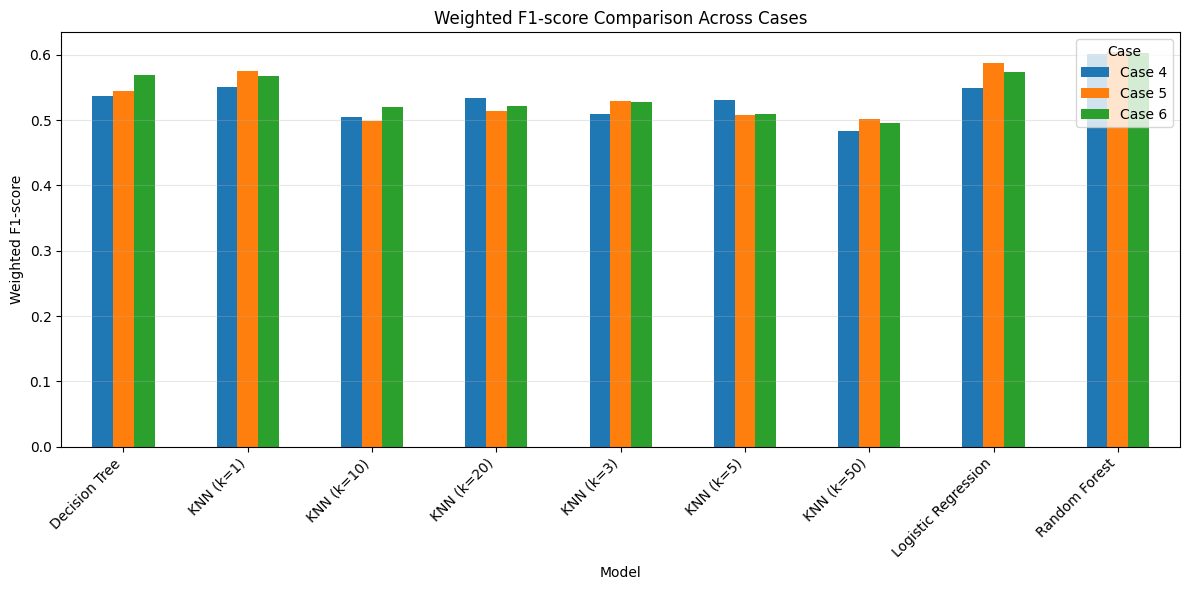

In [305]:
# F1-score Comparison
f1_table = results_all_classification.pivot(
    index="Model",
    columns="Case",
    values="F1"
)

f1_table.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Weighted F1-score Comparison Across Cases")
plt.ylabel("Weighted F1-score")
plt.xlabel("Model")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

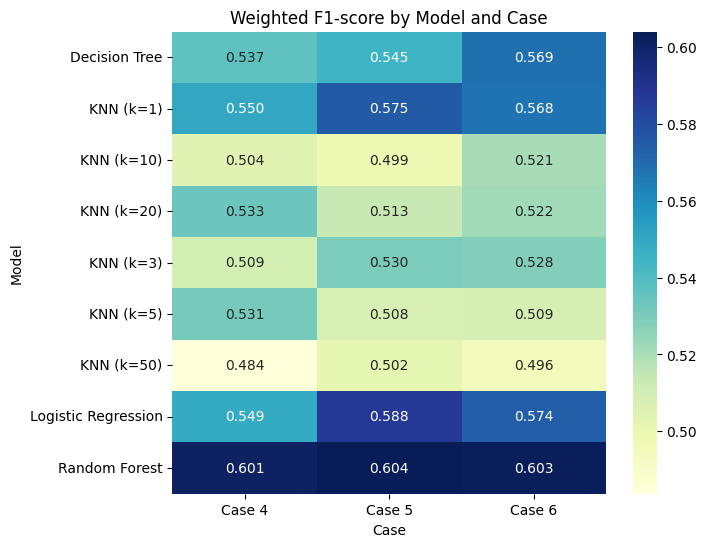

In [306]:
# Heatmap

heatmap = results_all_classification.pivot(
    index="Model",
    columns="Case",
    values="F1"
)

plt.figure(figsize=(7,6))

sns.heatmap(
    heatmap,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Weighted F1-score by Model and Case")

plt.show()

## 10. Discussion and Conclusion
Discuss which feature engineering approach and algorithm performed best, and whether categorizing pH and residual sugar improved performance.